# What will be my budget after I sell my house ?

**Author** : Léna Rebours

I would like to move and start looking for a new home, but I would like to know what my budget is after selling my current home


**Objective : Predict the price of a house**

The dataset contains information on the characteristics of houses and their associated price.

## 1. Library Import

In [123]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.neural_network import MLPRegressor


In [124]:
def plot_sorted_coefficients(coef, threshold = 1e-08):
    """
    Plots a sorted scatter plot of logistic regression coefficients with different colors
    for positive, negative, and near-zero coefficients.
    
    Parameters:
    - coef: A pandas Series or array-like object containing coefficients.
    - threshold: A float value used to classify near-zero coefficients. Default is 1e-08.
    """

    # Sort the coefficients by their absolute values
    sorted_coef = coef.abs().sort_values()
    
    # Get the original coefficients for coloring
    original_sorted_coef = coef.loc[sorted_coef.index]
    
    # Create a scatter plot with bars
    plt.figure(figsize=(8, 32))
    
    # Plot positive coefficients in blue, negative coefficients in yellow, and near-zero coefficients in grey
    colors = [
        'grey' if abs(c) < threshold else 'green' if c > 0 else 'red'
        for c in original_sorted_coef
    ]
    
    # Scatter plot for coefficients
    plt.scatter(sorted_coef.values, sorted_coef.index, color = colors, zorder = 5)
    
    # Plot lines from the origin to the scatter points
    for i in range(len(sorted_coef)):
        plt.plot([0, sorted_coef.values[i]], [i, i], color = 'skyblue', lw = 2)
    
    # Add vertical line at zero
    plt.axvline(x = 0, color = 'gray', linestyle = '--', linewidth = 1)
    
    # Set labels and title
    plt.xlabel('Absolute Coefficient Value')
    plt.ylabel('Feature')
    plt.title('Logistic Regression Coefficients (Absolute Values)')
    
    # Show the plot
    plt.show()

## 2. Data Import

In [125]:
df = pd.read_csv("housing_prices.csv")
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


C:\Users\Léna\AppData\Roaming\Python\Python311\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Léna\AppData\Roaming\Python\Python311\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


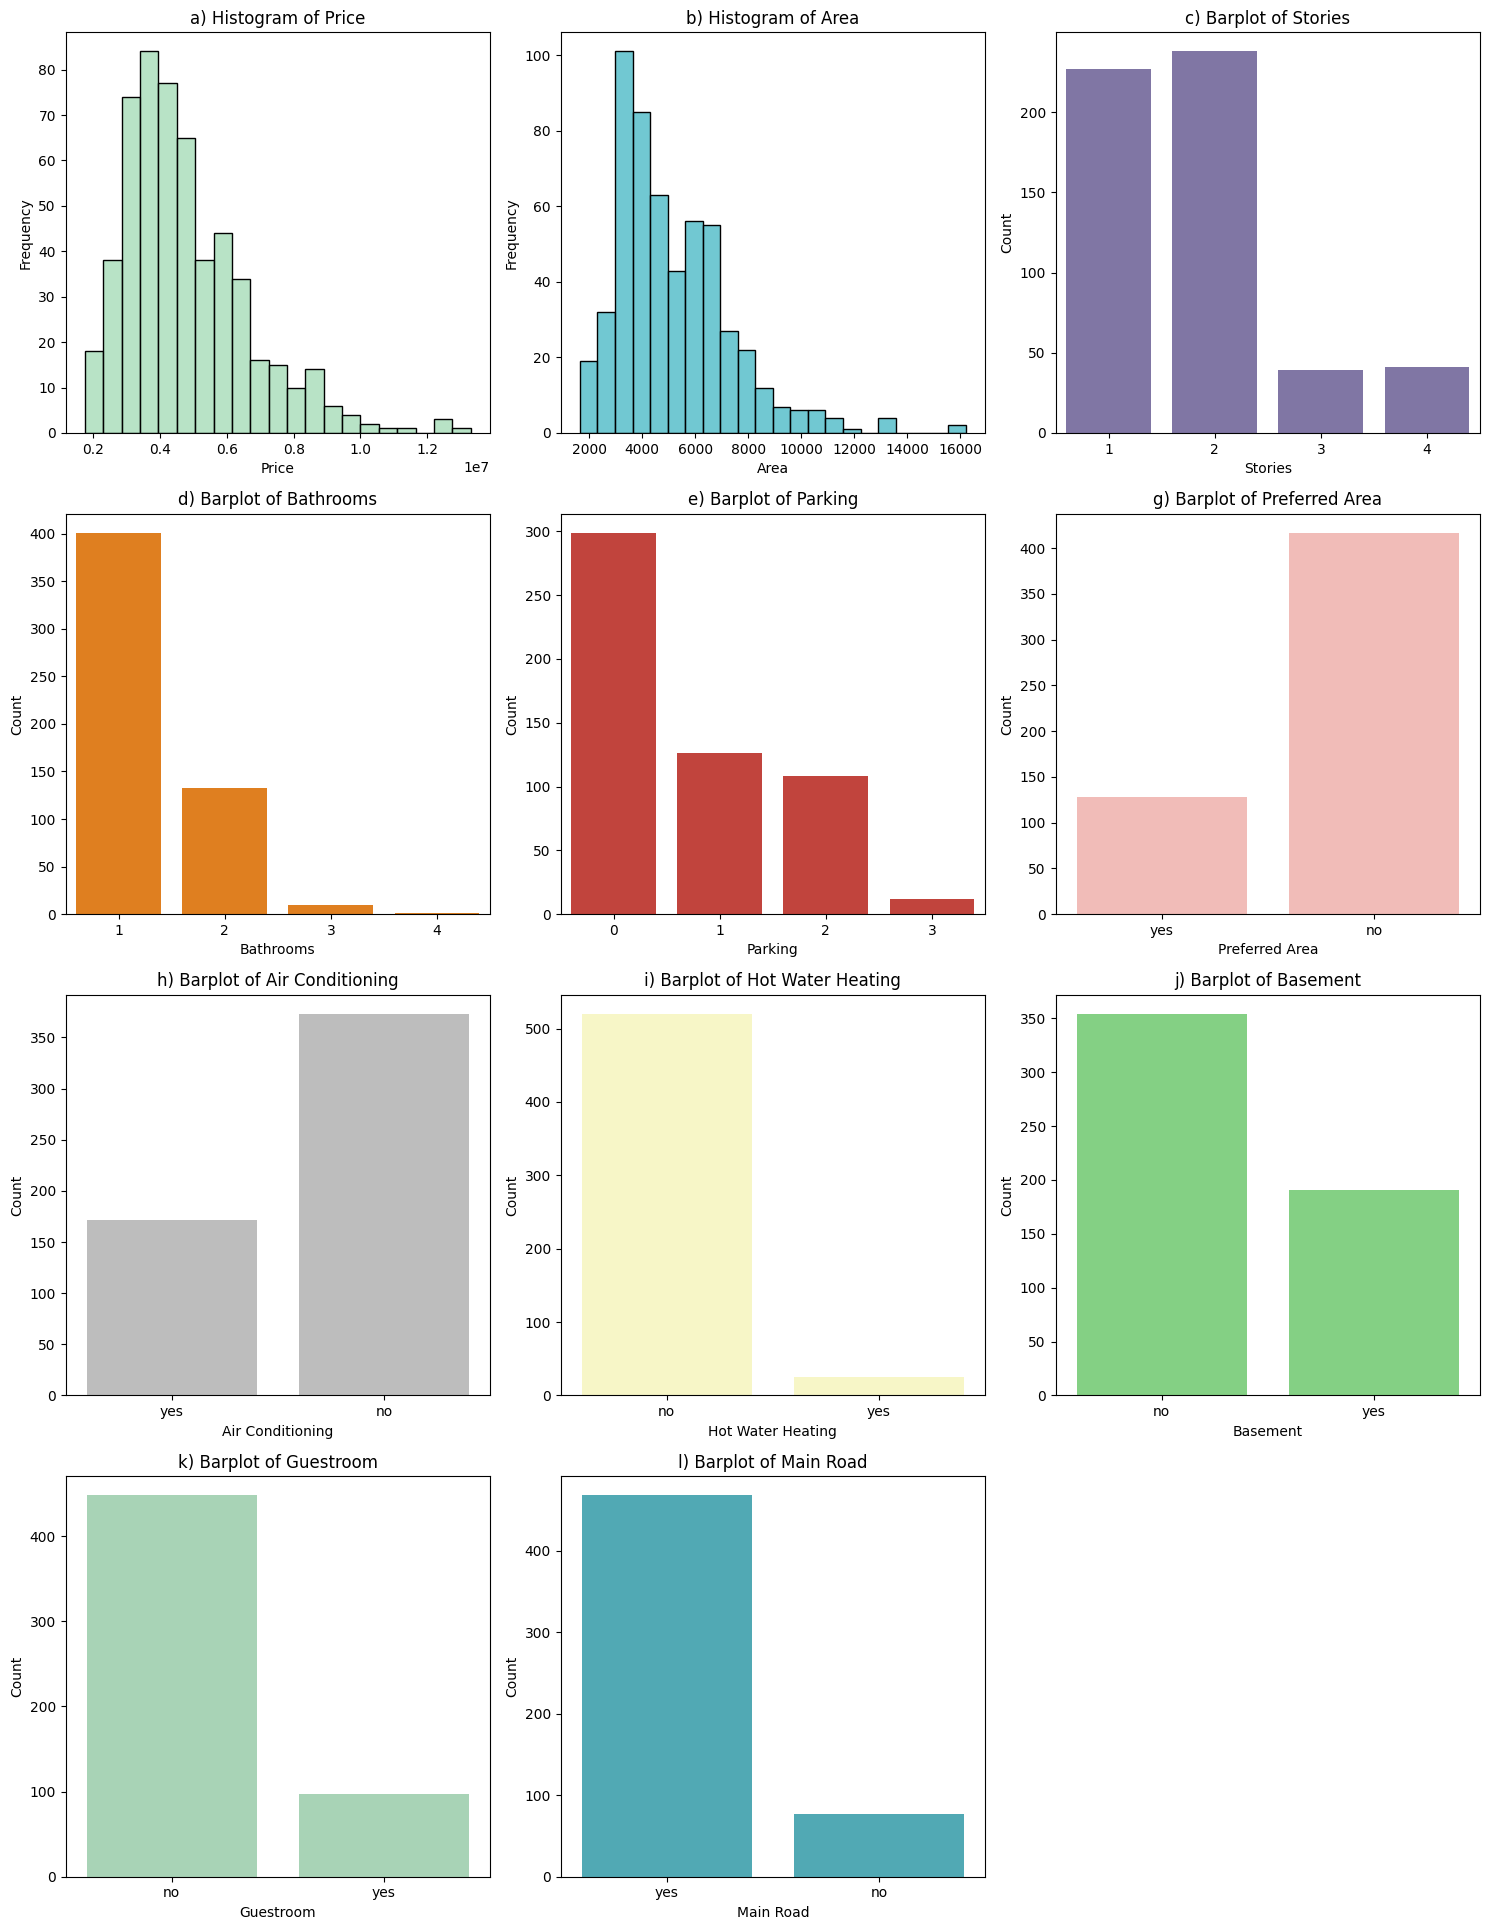

In [126]:
# Define the overall figure size and the main title
fig1 = plt.figure(figsize=(15, 20))

# Define a list of pastel color palettes for each chart
palettes = ['#a1dab4', '#41b6c4', '#7b6eac', '#ff7f00', '#d73027', '#fdae00', '#fbb4ae', '#bdbdbd', '#fffebf', '#77dd77']

# Chart 1: Histogram for "price"
plt.subplot(4, 3, 1)
sns.histplot(df['price'], kde=False, color=palettes[0])
plt.title('a) Histogram of Price')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.tight_layout()

# Chart 2: Histogram for "area"
plt.subplot(4, 3, 2)
sns.histplot(df['area'], kde=False, color=palettes[1])
plt.title('b) Histogram of Area')
plt.xlabel('Area')
plt.ylabel('Frequency')
plt.tight_layout()

# Chart 3: Bar plot for "stories"
plt.subplot(4, 3, 3)
sns.countplot(x='stories', data=df, palette=[palettes[2]])
plt.title('c) Barplot of Stories')
plt.xlabel('Stories')
plt.ylabel('Count')
plt.tight_layout()

# Chart 4: Bar plot for "bathrooms"
plt.subplot(4, 3, 4)
sns.countplot(x='bathrooms', data=df, palette=[palettes[3]])
plt.title('d) Barplot of Bathrooms')
plt.xlabel('Bathrooms')
plt.ylabel('Count')
plt.tight_layout()

# Chart 5: Bar plot for "parking"
plt.subplot(4, 3, 5)
sns.countplot(x='parking', data=df, palette=[palettes[4]])
plt.title('e) Barplot of Parking')
plt.xlabel('Parking')
plt.ylabel('Count')
plt.tight_layout()

# Chart 6: Bar plot for "prefarea"
plt.subplot(4, 3, 6)
sns.countplot(x='prefarea', data=df, palette=[palettes[6]])
plt.title('g) Barplot of Preferred Area')
plt.xlabel('Preferred Area')
plt.ylabel('Count')
plt.tight_layout()

# Chart 7: Bar plot for "airconditioning"
plt.subplot(4, 3, 7)
sns.countplot(x='airconditioning', data=df, palette=[palettes[7]])
plt.title('h) Barplot of Air Conditioning')
plt.xlabel('Air Conditioning')
plt.ylabel('Count')
plt.tight_layout()

# Chart 8: Bar plot for "hotwaterheating"
plt.subplot(4, 3, 8)
sns.countplot(x='hotwaterheating', data=df, palette=[palettes[8]])
plt.title('i) Barplot of Hot Water Heating')
plt.xlabel('Hot Water Heating')
plt.ylabel('Count')
plt.tight_layout()

# Chart 9: Bar plot for "basement"
plt.subplot(4, 3, 9)
sns.countplot(x='basement', data=df, palette=[palettes[9]])
plt.title('j) Barplot of Basement')
plt.xlabel('Basement')
plt.ylabel('Count')
plt.tight_layout()

# Chart 10: Bar plot for "guestroom"
plt.subplot(4, 3, 10)
sns.countplot(x='guestroom', data=df, palette=[palettes[0]])
plt.title('k) Barplot of Guestroom')
plt.xlabel('Guestroom')
plt.ylabel('Count')
plt.tight_layout()

# Chart 11: Bar plot for "mainroad"
plt.subplot(4, 3, 11)
sns.countplot(x='mainroad', data=df, palette=[palettes[1]])
plt.title('l) Barplot of Main Road')
plt.xlabel('Main Road')
plt.ylabel('Count')
plt.tight_layout()

# Adjust the spacing for the main title
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


## 3. Data Manipulation

In [127]:
# Divide the values in the 'price' column by 100000
df['price'] = df['price'] / 100000

# Display the first rows of the DataFrame to verify the changes
print(df.head())

    price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  133.00  7420         4          2        3      yes        no       no   
1  122.50  8960         4          4        4      yes        no       no   
2  122.50  9960         3          2        2      yes        no      yes   
3  122.15  7500         4          2        2      yes        no      yes   
4  114.10  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  


## 4. Binarize data 

### 4.1. Transform a categorical column into a set of boolean columns

In [128]:
# Transform the 'furninshingstatus' column into dummy/boolean columns
df = pd.get_dummies(df, columns = ['furnishingstatus'], drop_first = True)
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,133.0000,7420,4,2,3,yes,no,no,no,yes,2,yes,False,False
1,122.5000,8960,4,4,4,yes,no,no,no,yes,3,no,False,False
2,122.5000,9960,3,2,2,yes,no,yes,no,no,2,yes,True,False
3,122.1500,7500,4,2,2,yes,no,yes,no,yes,3,yes,False,False
4,114.1000,7420,4,1,2,yes,yes,yes,no,yes,2,no,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,18.2000,3000,2,1,1,yes,no,yes,no,no,2,no,False,True
541,17.6715,2400,3,1,1,no,no,no,no,no,0,no,True,False
542,17.5000,3620,2,1,1,yes,no,no,no,no,0,no,False,True
543,17.5000,2910,3,1,1,no,no,no,no,no,0,no,False,False


### 4.2. Transform all boolean columns into integer columns

In [129]:
boolean_columns = df.select_dtypes(include = 'bool')  # Select columns with boolean data type
df[boolean_columns.columns] = df[boolean_columns.columns].astype(int)  # Convert True/False to 0/1

df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,133.0000,7420,4,2,3,yes,no,no,no,yes,2,yes,0,0
1,122.5000,8960,4,4,4,yes,no,no,no,yes,3,no,0,0
2,122.5000,9960,3,2,2,yes,no,yes,no,no,2,yes,1,0
3,122.1500,7500,4,2,2,yes,no,yes,no,yes,3,yes,0,0
4,114.1000,7420,4,1,2,yes,yes,yes,no,yes,2,no,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,18.2000,3000,2,1,1,yes,no,yes,no,no,2,no,0,1
541,17.6715,2400,3,1,1,no,no,no,no,no,0,no,1,0
542,17.5000,3620,2,1,1,yes,no,no,no,no,0,no,0,1
543,17.5000,2910,3,1,1,no,no,no,no,no,0,no,0,0


In [130]:
# Columns to transform
columns_to_transform = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']

# Apply the transformation 'yes' -> 1 and 'no' -> 0 to each column
df[columns_to_transform] = df[columns_to_transform].replace({'yes': 1, 'no': 0})

# Display the DataFrame
print(df)

        price  area  bedrooms  bathrooms  stories  mainroad  guestroom  \
0    133.0000  7420         4          2        3         1          0   
1    122.5000  8960         4          4        4         1          0   
2    122.5000  9960         3          2        2         1          0   
3    122.1500  7500         4          2        2         1          0   
4    114.1000  7420         4          1        2         1          1   
..        ...   ...       ...        ...      ...       ...        ...   
540   18.2000  3000         2          1        1         1          0   
541   17.6715  2400         3          1        1         0          0   
542   17.5000  3620         2          1        1         1          0   
543   17.5000  2910         3          1        1         0          0   
544   17.5000  3850         3          1        2         1          0   

     basement  hotwaterheating  airconditioning  parking  prefarea  \
0           0                0           

C:\Users\Léna\AppData\Local\Temp\ipykernel_7540\3939198782.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[columns_to_transform] = df[columns_to_transform].replace({'yes': 1, 'no': 0})


## 5. Price prediction

### 5.1. Data normalization

In [131]:
cols = [col for col in df.drop('price', axis = 1).columns]

scaler = StandardScaler()
df[cols] = pd.DataFrame(scaler.fit_transform(df[cols]), index = df.index)
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,133.0000,1.046726,1.403419,1.421812,1.378217,0.405623,-0.465315,-0.734539,-0.219265,1.472618,1.517692,1.804941,-0.844888,-0.696429
1,122.5000,1.757010,1.403419,5.405809,2.532024,0.405623,-0.465315,-0.734539,-0.219265,1.472618,2.679409,-0.554035,-0.844888,-0.696429
2,122.5000,2.218232,0.047278,1.421812,0.224410,0.405623,-0.465315,1.361397,-0.219265,-0.679063,1.517692,1.804941,1.183588,-0.696429
3,122.1500,1.083624,1.403419,1.421812,0.224410,0.405623,-0.465315,1.361397,-0.219265,1.472618,2.679409,1.804941,-0.844888,-0.696429
4,114.1000,1.046726,1.403419,-0.570187,0.224410,0.405623,2.149083,1.361397,-0.219265,1.472618,1.517692,-0.554035,-0.844888,-0.696429
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,18.2000,-0.991879,-1.308863,-0.570187,-0.929397,0.405623,-0.465315,1.361397,-0.219265,-0.679063,1.517692,-0.554035,-0.844888,1.435896
541,17.6715,-1.268613,0.047278,-0.570187,-0.929397,-2.465344,-0.465315,-0.734539,-0.219265,-0.679063,-0.805741,-0.554035,1.183588,-0.696429
542,17.5000,-0.705921,-1.308863,-0.570187,-0.929397,0.405623,-0.465315,-0.734539,-0.219265,-0.679063,-0.805741,-0.554035,-0.844888,1.435896
543,17.5000,-1.033389,0.047278,-0.570187,-0.929397,-2.465344,-0.465315,-0.734539,-0.219265,-0.679063,-0.805741,-0.554035,-0.844888,-0.696429


### 5.2. Train / Test split

In [132]:
X = df.drop("price", axis = 1)
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 666)

### 5.3. Linear regression

In [133]:
# Performing Linear Regression
reg = LinearRegression()
reg.fit(X_train, y_train)

coef = pd.Series(reg.coef_, index = X.columns)


In [134]:
# Test the linear regression
y_pred = reg.predict(X_test)

In [135]:
# Compute the rooted mean square error
np.sqrt(mean_squared_error(y_test, y_pred))

np.float64(10.604014776167919)

In [136]:
mean_absolute_error(y_test, y_pred)

np.float64(7.764085424340154)

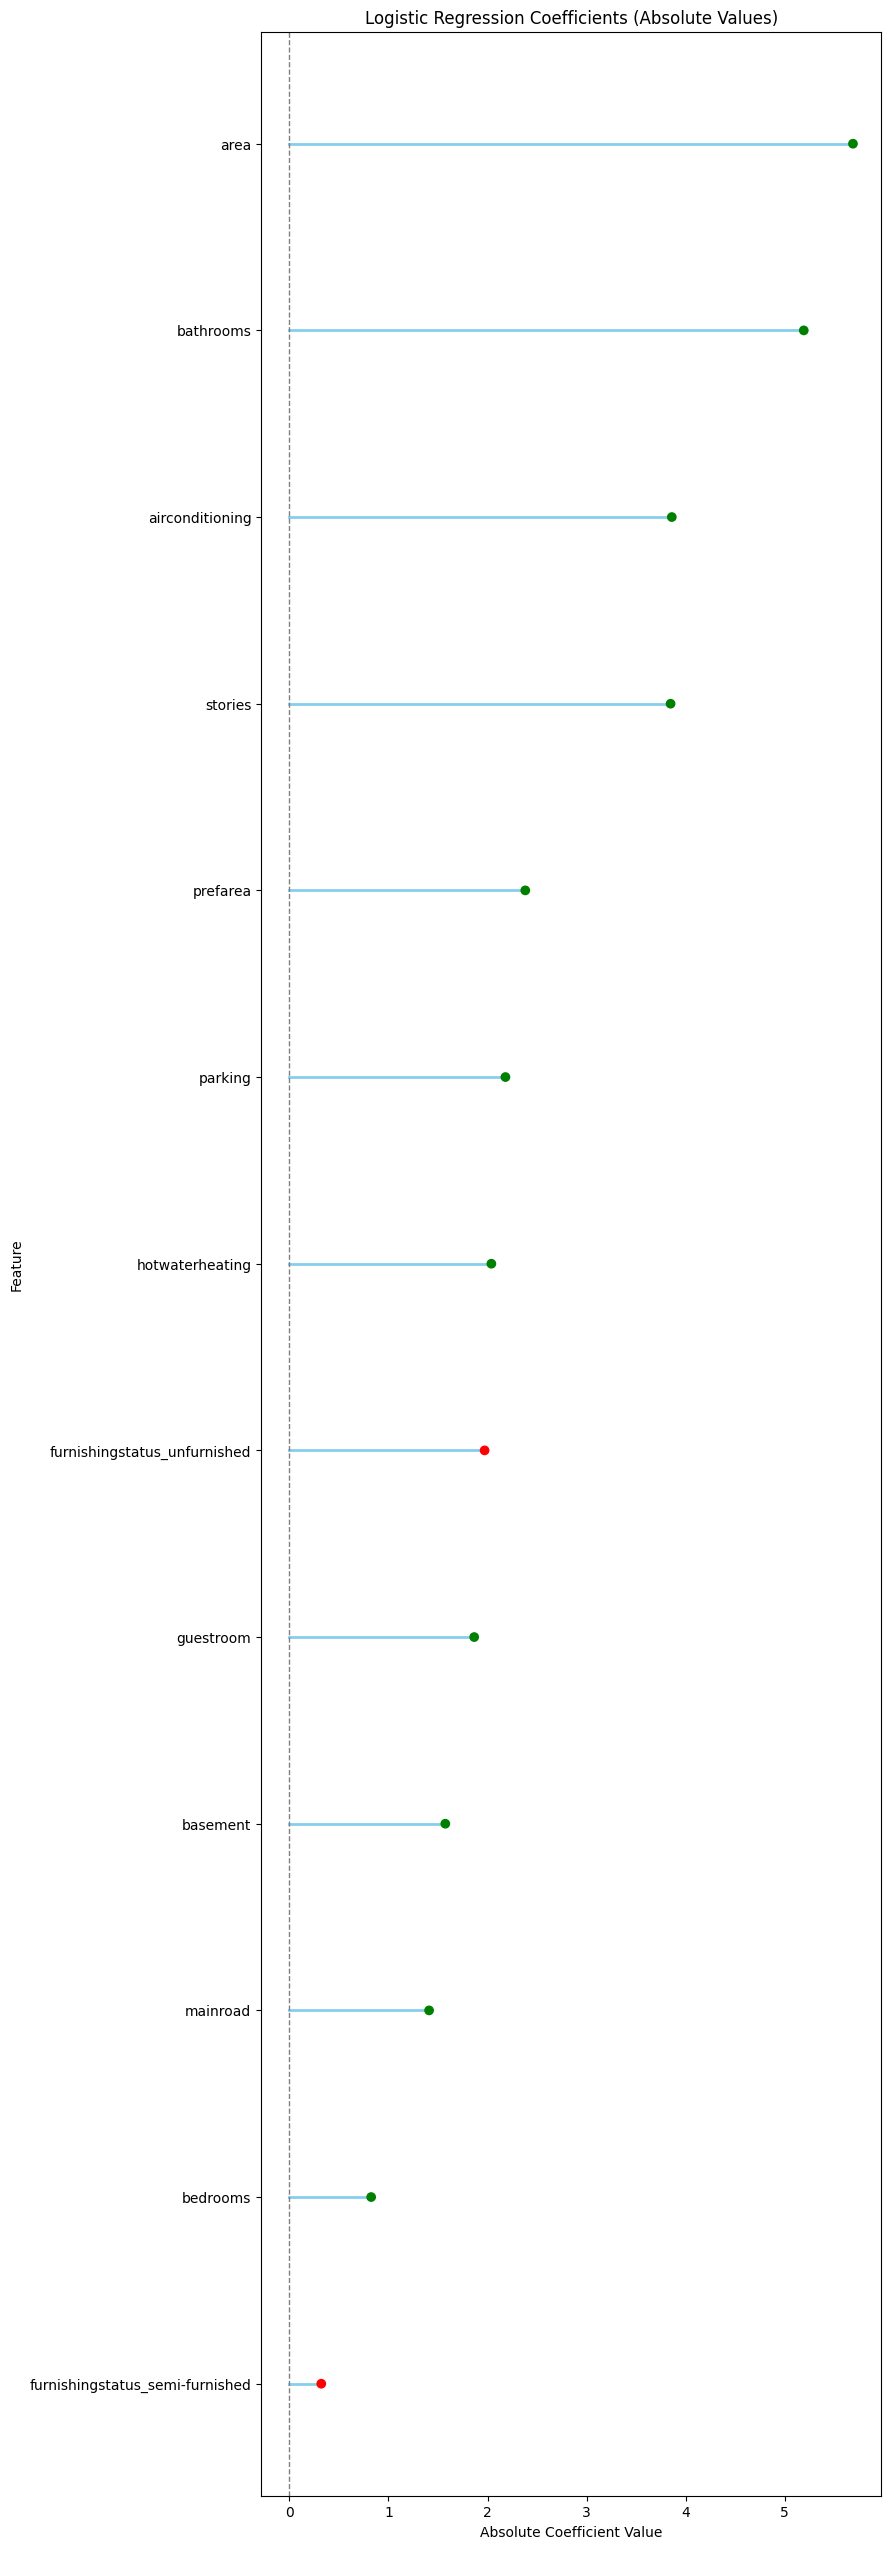

In [137]:
plot_sorted_coefficients(coef)

Text(0, 0.5, 'Predicted price')

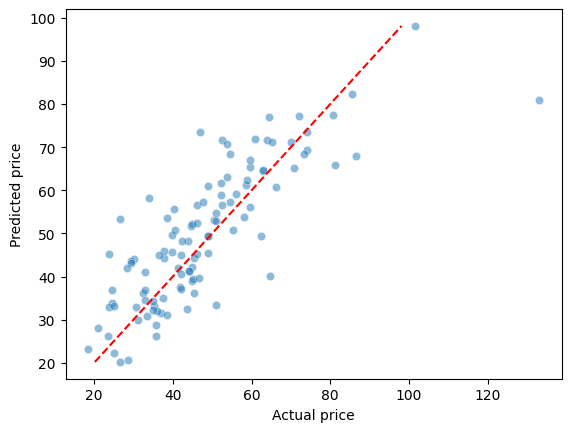

In [138]:
sns.scatterplot(x = y_test, y = y_pred, alpha = 0.5)
plt.plot([min(y_pred), max(y_pred)], [min(y_pred), max(y_pred)], linestyle='--', color='red')
plt.xlabel("Actual price")
plt.ylabel("Predicted price")

### 5.4 LASSO Regression

In [139]:
# Performing LASSO Regression
reg = Lasso(alpha = 0.5)
reg.fit(X_train, y_train)

coef = pd.Series(reg.coef_, index = X.columns)

In [140]:
# Test the regression
y_pred = reg.predict(X_test)

In [141]:
# Compute the rooted mean square error
np.sqrt(mean_squared_error(y_test, y_pred))

np.float64(10.490044598900061)

In [142]:
mean_absolute_error(y_test, y_pred)

np.float64(7.4828523370904705)

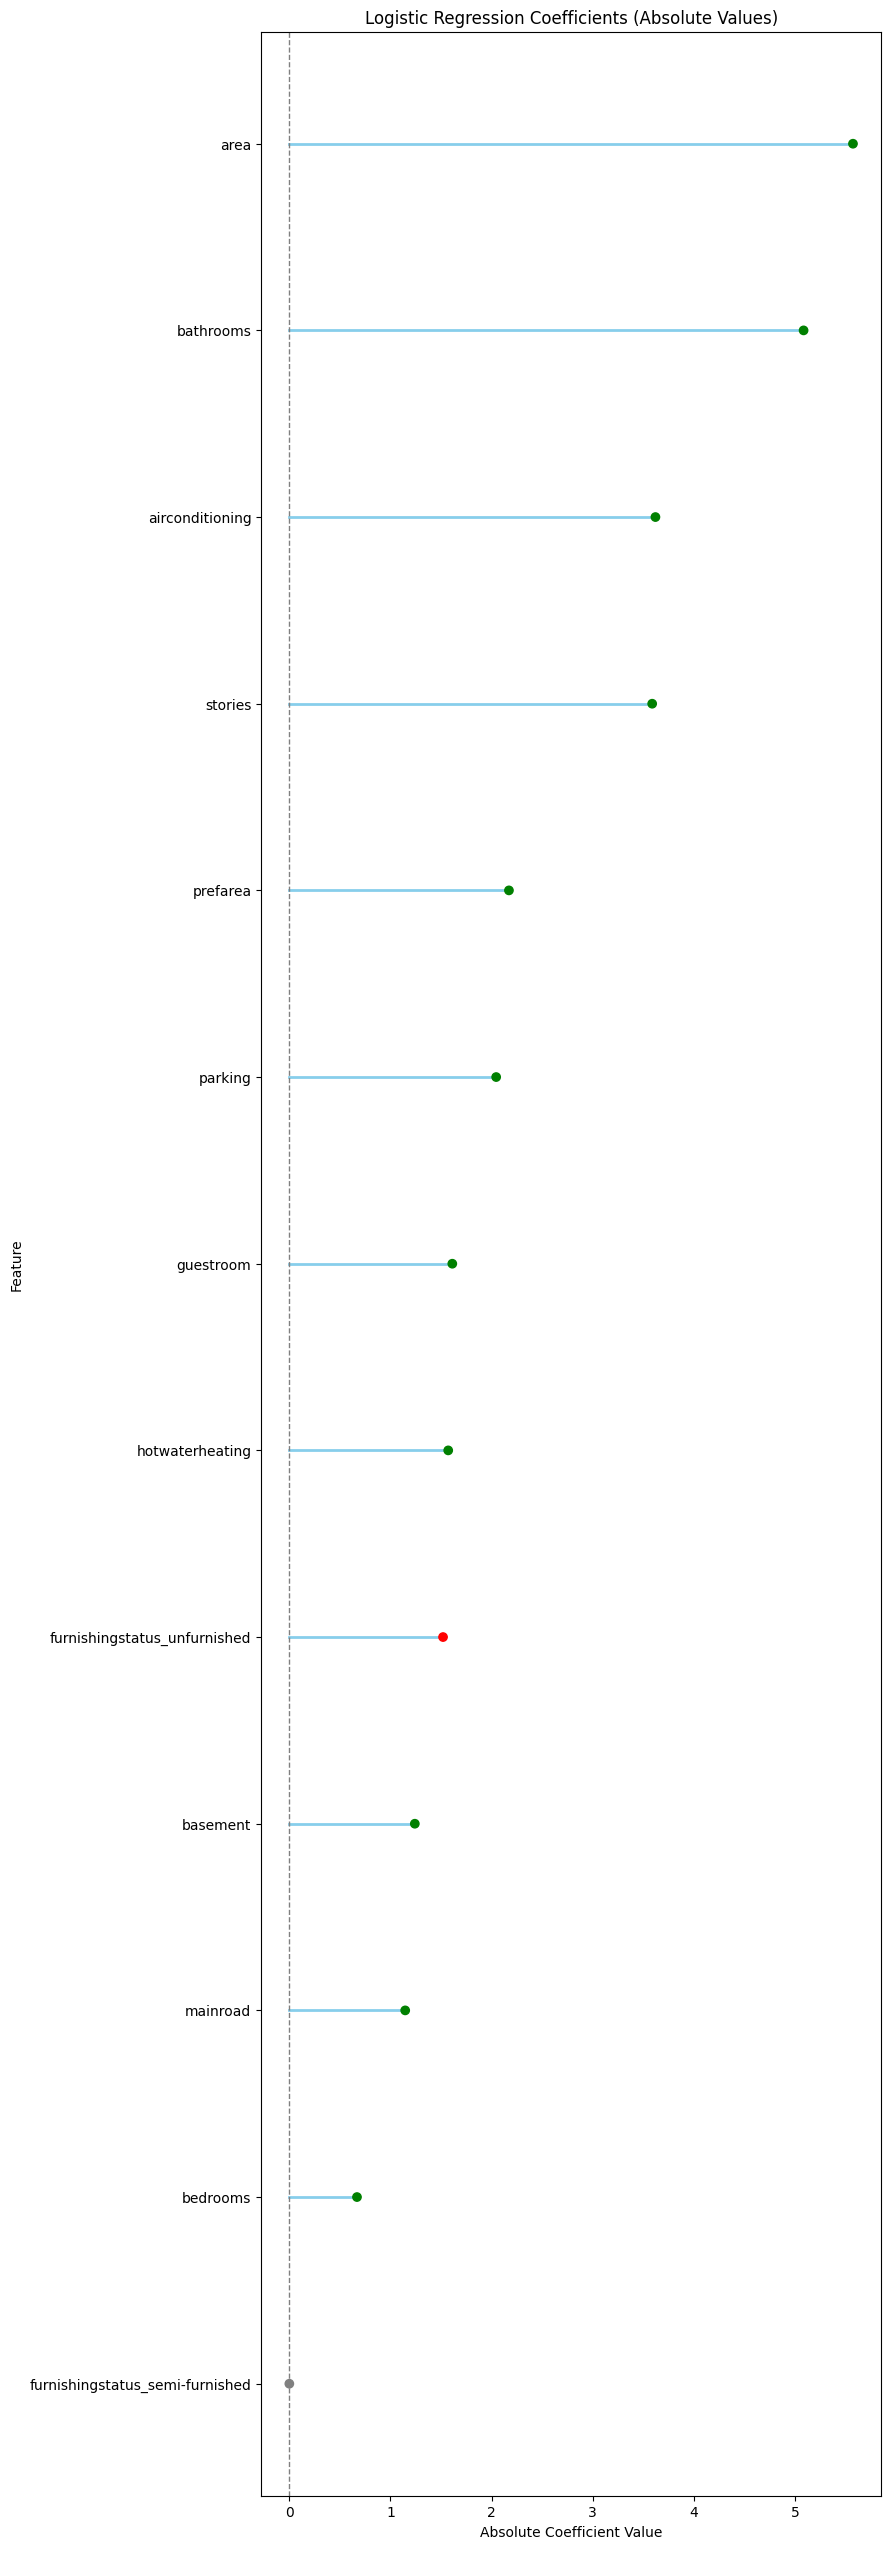

In [143]:
plot_sorted_coefficients(coef)

Text(0, 0.5, 'Predicted price')

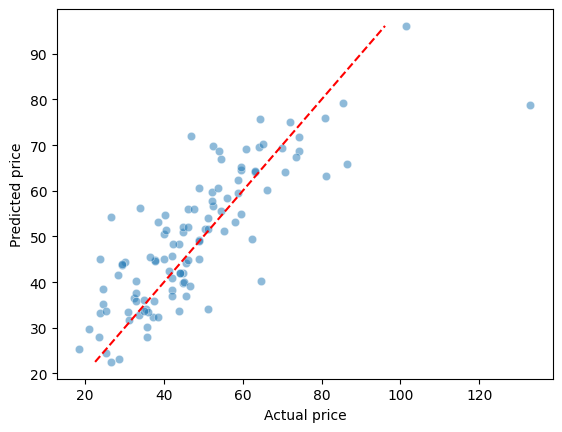

In [144]:
sns.scatterplot(x = y_test, y = y_pred,  alpha = 0.5)
plt.plot([min(y_pred), max(y_pred)], [min(y_pred), max(y_pred)], linestyle='--', color='red')
plt.xlabel("Actual price")
plt.ylabel("Predicted price")

### 5.5. Neural Network

In [145]:
# Large Neural Network with three hidden layers ([100,50] neurons)
clf_150_neurons = MLPRegressor(hidden_layer_sizes = (100,50), activation = 'relu',
                              solver='adam', max_iter = 1000, alpha = 10, tol = 1e-6, batch_size= 1000,
                              random_state = 666, verbose = True
                              )

# Train the network
clf_150_neurons.fit(X_train, y_train)

# Predict on the test set
y_pred = clf_150_neurons.predict(X_test)

C:\Users\Léna\AppData\Roaming\Python\Python311\site-packages\sklearn\neural_network\_multilayer_perceptron.py:608: UserWarning: Got `batch_size` less than 1 or larger than sample size. It is going to be clipped
  warnings.warn(


Iteration 1, loss = 1304.23329575
Iteration 2, loss = 1299.40857771
Iteration 3, loss = 1294.58849314
Iteration 4, loss = 1289.76939831
Iteration 5, loss = 1284.94536143
Iteration 6, loss = 1280.11966762
Iteration 7, loss = 1275.25975786
Iteration 8, loss = 1270.35549726
Iteration 9, loss = 1265.41094558
Iteration 10, loss = 1260.42895435
Iteration 11, loss = 1255.38099060
Iteration 12, loss = 1250.25358109
Iteration 13, loss = 1245.03964337
Iteration 14, loss = 1239.73265878
Iteration 15, loss = 1234.33054640
Iteration 16, loss = 1228.81730466
Iteration 17, loss = 1223.19645712
Iteration 18, loss = 1217.44823612
Iteration 19, loss = 1211.55904022
Iteration 20, loss = 1205.51714684
Iteration 21, loss = 1199.33585825
Iteration 22, loss = 1193.00695257
Iteration 23, loss = 1186.52603201
Iteration 24, loss = 1179.88164401
Iteration 25, loss = 1173.06709497
Iteration 26, loss = 1166.07229668
Iteration 27, loss = 1158.89770376
Iteration 28, loss = 1151.53492964
Iteration 29, loss = 1143.971

C:\Users\Léna\AppData\Roaming\Python\Python311\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


In [146]:
# Test the regression
y_pred = reg.predict(X_test)

In [147]:
# Compute the rooted mean square error
np.sqrt(mean_squared_error(y_test, y_pred))

np.float64(10.490044598900061)

In [148]:
mean_absolute_error(y_test, y_pred)

np.float64(7.4828523370904705)

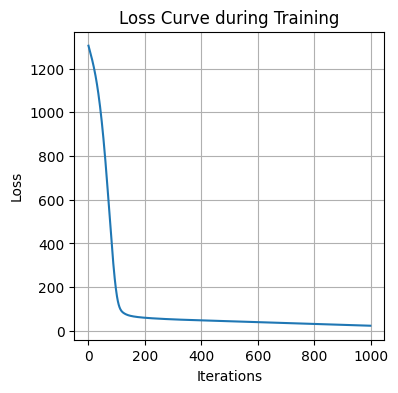

In [149]:
# Plot the loss curve
plt.figure(figsize = (4, 4))
plt.plot(clf_150_neurons.loss_curve_)
plt.title('Loss Curve during Training')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

Text(0, 0.5, 'Predicted price')

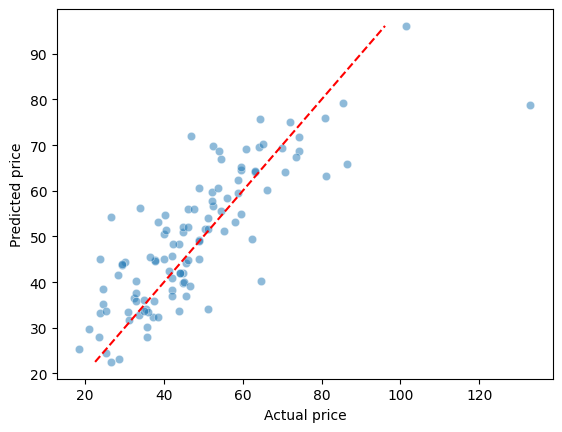

In [150]:
sns.scatterplot(x = y_test, y = y_pred,  alpha = 0.5)
plt.plot([min(y_pred), max(y_pred)], [min(y_pred), max(y_pred)], linestyle='--', color='red')
plt.xlabel("Actual price")
plt.ylabel("Predicted price")

## 6. Conclusion

The mean absolute error is equal to 7.483%, and is minimized by LASSO regression or neural network (equivalent performance). It therefore is possible to predict the price of a house.